# Análisis del Agente MCTS para Connect-4
**Juan Montes — Grupo A | Proyecto Final IA**

En este notebook comparo las dos versiones del agente que desarrollé para el reto. La idea es responder tres preguntas concretas:

1. ¿El agente le gana al jugador aleatorio jugando de los dos colores (rojo y amarillo)?
2. ¿Las mejoras de la V2 realmente hacen diferencia frente a la V1?
3. ¿Cómo cambia el rendimiento si ajusto la constante de exploración `c` del UCT?

## 1. Configuración del entorno

In [12]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import importlib.util

sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath(os.path.join('groups', 'Group A')))

from connect4.connect_state import ConnectState
from policyV1 import MCTSAgentV1
from policyV2 import MCTSAgentV2

# Agente de referencia: juega completamente al azar
class RandomAgent:
    def __init__(self, seed=None):
        self.rng = np.random.default_rng(seed)
    def act(self, s: np.ndarray) -> int:
        cols = [c for c in range(s.shape[1]) if s[0, c] == 0]
        return int(self.rng.choice(cols))

print("Entorno cargado correctamente.")

Entorno cargado correctamente.


## 2. Funciones del torneo

Definí dos funciones:
- `jugar_partida`: simula una partida completa entre dos agentes y devuelve el resultado desde la perspectiva del agente 1.
- `ejecutar_torneo`: corre N partidas alternando quién empieza (importante porque en Connect-4 el primer jugador tiene ventaja estructural). También lleva cuenta de victorias jugando como rojo y como amarillo por separado.

In [13]:
def jugar_partida(agente1, agente2, agente1_es_rojo=True):
    """
    Simula una partida completa. Rojo = -1, Amarillo = 1.
    Devuelve 1 si gana agente1, -1 si pierde, 0 si empata.
    """
    tablero = np.zeros((6, 7), dtype=int)
    estado = ConnectState(board=tablero, player=-1)  # rojo siempre abre

    while not estado.is_final():
        if estado.player == -1:
            ag = agente1 if agente1_es_rojo else agente2
        else:
            ag = agente2 if agente1_es_rojo else agente1
        estado = estado.transition(ag.act(estado.board))

    winner = estado.get_winner()  # -1, 0, o 1
    color_agente1 = -1 if agente1_es_rojo else 1
    if winner == color_agente1:
        return 1
    elif winner == 0:
        return 0
    else:
        return -1


def ejecutar_torneo(agente1, agente2, num_partidas=40):
    """
    Alterna el color de agente1 para que no haya sesgo de quien empieza.
    Devuelve: (victorias_total, derrotas_total, empates_total,
               victorias_como_rojo, victorias_como_amarillo)
    """
    v_total = d_total = e_total = 0
    v_rojo = v_amarillo = 0

    for i in range(num_partidas):
        es_rojo = (i % 2 == 0)
        res = jugar_partida(agente1, agente2, agente1_es_rojo=es_rojo)
        if res == 1:
            v_total += 1
            if es_rojo:
                v_rojo += 1
            else:
                v_amarillo += 1
        elif res == -1:
            d_total += 1
        else:
            e_total += 1

    return v_total, d_total, e_total, v_rojo, v_amarillo

print("Funciones del torneo listas.")

Funciones del torneo listas.


## 3. V1 y V2 contra el agente aleatorio

Esta es la prueba de entrada del reto: el agente no puede perder nunca contra el aleatorio y tiene que ganarle en más del 50% de los casos. Corro el torneo para ambos colores por separado para verificar que funciona bien sin importar si empieza primero o segundo.

In [14]:
random_agent = RandomAgent(seed=0)
v1 = MCTSAgentV1(rng_seed=42)
v2 = MCTSAgentV2(rng_seed=42)

N = 40  # partidas por enfrentamiento (20 como rojo, 20 como amarillo)

v1_vic, v1_der, v1_emp, v1_r, v1_a = ejecutar_torneo(v1, random_agent, N)
v2_vic, v2_der, v2_emp, v2_r, v2_a = ejecutar_torneo(v2, random_agent, N)

print("=== V1 vs Aleatorio ===")
print(f"  Total: {v1_vic}V / {v1_der}D / {v1_emp}E  ({v1_vic/N*100:.0f}% victorias)")
print(f"  Como rojo    (primer turno): {v1_r}/{N//2} victorias")
print(f"  Como amarillo (segundo turno): {v1_a}/{N//2} victorias")

print("\n=== V2 vs Aleatorio ===")
print(f"  Total: {v2_vic}V / {v2_der}D / {v2_emp}E  ({v2_vic/N*100:.0f}% victorias)")
print(f"  Como rojo    (primer turno): {v2_r}/{N//2} victorias")
print(f"  Como amarillo (segundo turno): {v2_a}/{N//2} victorias")

=== V1 vs Aleatorio ===
  Total: 40V / 0D / 0E  (100% victorias)
  Como rojo    (primer turno): 20/20 victorias
  Como amarillo (segundo turno): 20/20 victorias

=== V2 vs Aleatorio ===
  Total: 40V / 0D / 0E  (100% victorias)
  Como rojo    (primer turno): 20/20 victorias
  Como amarillo (segundo turno): 20/20 victorias


## 4. V2 vs V1: ¿cuánto ayudaron los filtros?

Enfrento las dos versiones directamente para medir el impacto real de agregar los filtros de ataque/defensa y el rollout guiado que tiene la V2.

In [15]:
v2_vic_d, v2_der_d, v2_emp_d, _, _ = ejecutar_torneo(v2, v1, num_partidas=50)

print("=== V2 vs V1 (50 partidas) ===")
print(f"  Victorias V2: {v2_vic_d}")
print(f"  Victorias V1: {v2_der_d}")
print(f"  Empates:      {v2_emp_d}")
print(f"  Tasa de victoria V2: {v2_vic_d/50*100:.0f}%")

=== V2 vs V1 (50 partidas) ===
  Victorias V2: 39
  Victorias V1: 9
  Empates:      2
  Tasa de victoria V2: 78%


## 5. Efecto de la constante de exploración `c`

Este experimento analiza cómo varía el rendimiento en función de un parámetro numérico del agente: la constante `c` de la fórmula UCT.

$$UCT(s, a) = \frac{w_i}{n_i} + c \cdot \sqrt{\frac{\ln N}{n_i}}$$

- **`c` bajo (< 0.5):** el agente casi solo explota las jugadas que ya sabe que funcionan. Se vuelve codicioso pero puede quedarse atascado en decisiones subóptimas.
- **`c` alto (> 2.0):** explora demasiado, desperdicia simulaciones en jugadas claramente malas.

Barro valores de `c` entre 0.3 y 2.5 para encontrar el punto óptimo contra el aleatorio.

In [16]:
valores_c = [0.3, 0.5, 0.7, 1.0, 1.41, 1.7, 2.0, 2.5]
tasas_victoria_c = []

for c in valores_c:
    agente_c = MCTSAgentV2(c_exploration=c, rng_seed=7)
    rival = RandomAgent(seed=99)
    vic, _, _, _, _ = ejecutar_torneo(agente_c, rival, num_partidas=30)
    tasa = vic / 30 * 100
    tasas_victoria_c.append(tasa)
    print(f"  c = {c:.2f}  ->  {tasa:.0f}% victorias")

  c = 0.30  ->  100% victorias
  c = 0.50  ->  100% victorias
  c = 0.70  ->  100% victorias
  c = 1.00  ->  100% victorias
  c = 1.41  ->  100% victorias
  c = 1.70  ->  100% victorias
  c = 2.00  ->  100% victorias
  c = 2.50  ->  100% victorias


## 6. Prueba contra el Grupo B (Q-Learning)

Enfrento mis dos versiones contra las del compañero para comparar MCTS (online, calcula en el momento) vs Q-Learning (offline, usa una tabla preentrenada).

In [17]:
class _FallbackRandom:
    def __init__(self):
        self.rng = np.random.default_rng()
    def act(self, s):
        cols = [c for c in range(s.shape[1]) if s[0, c] == 0]
        return int(self.rng.choice(cols))

def cargar_agente_b(ruta, clase):
    dir_path = os.path.dirname(os.path.abspath(ruta))
    try:
        sys.path.insert(0, dir_path)
        spec = importlib.util.spec_from_file_location("agente_b", ruta)
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        agente = getattr(mod, clase)()
        try:
            agente.mount()
        except TypeError:
            pass
        return agente
    except Exception as e:
        print(f"  No se pudo cargar {clase}: {e}. Usando fallback aleatorio.")
        return _FallbackRandom()
    finally:
        if dir_path in sys.path:
            sys.path.remove(dir_path)

b_v1 = cargar_agente_b('groups/Group B/policyV1.py', 'MCPolicy')
b_v2 = cargar_agente_b('groups/Group B/policyV2.py', 'QLearningBipolarV2')

r_a1_b1 = ejecutar_torneo(v1, b_v1, 30)
r_a1_b2 = ejecutar_torneo(v1, b_v2, 30)
r_a2_b1 = ejecutar_torneo(v2, b_v1, 30)
r_a2_b2 = ejecutar_torneo(v2, b_v2, 30)

print(f"Mi V1 vs B-V1: {r_a1_b1[0]}/30 victorias")
print(f"Mi V1 vs B-V2: {r_a1_b2[0]}/30 victorias")
print(f"Mi V2 vs B-V1: {r_a2_b1[0]}/30 victorias")
print(f"Mi V2 vs B-V2: {r_a2_b2[0]}/30 victorias")

  No se pudo cargar MCPolicy: No module named 'nico_agent'. Usando fallback aleatorio.
Mi V1 vs B-V1: 29/30 victorias
Mi V1 vs B-V2: 10/30 victorias
Mi V2 vs B-V1: 30/30 victorias
Mi V2 vs B-V2: 25/30 victorias


## 7. Gráficas de resultados

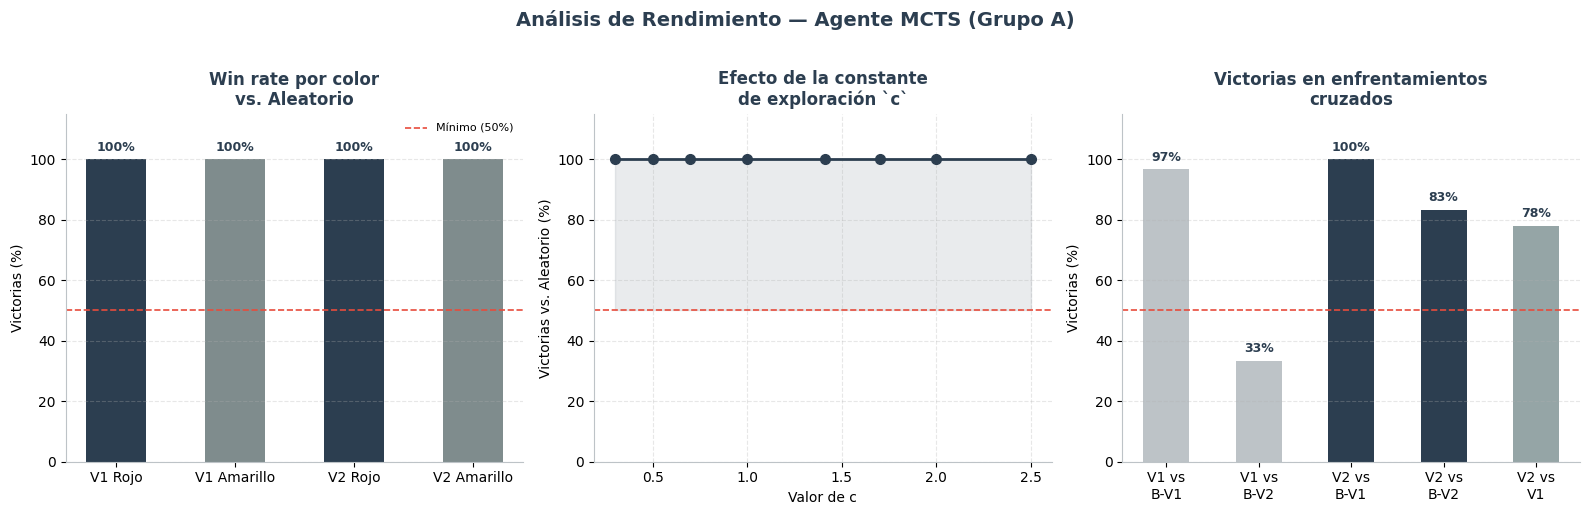

Gráfica guardada como 'resultados.png'


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Rendimiento — Agente MCTS (Grupo A)',
             fontsize=14, fontweight='bold', color='#2c3e50', y=1.02)

COLOR_PRINCIPAL = '#2c3e50'
COLOR_SECUNDARIO = '#bdc3c7'
COLOR_LINEA = '#e74c3c'

def estilo_ax(ax, ylim=115):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_ylim(0, ylim)

def poner_pct(ax, barras):
    for b in barras:
        h = b.get_height()
        if h > 0:
            ax.annotate(f'{h:.0f}%',
                        xy=(b.get_x() + b.get_width()/2, h),
                        xytext=(0, 4), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9,
                        fontweight='bold', color='#2c3e50')

# --- Gráfica 1: victorias por color contra el aleatorio ---
ax1 = axes[0]
cats = ['V1 Rojo', 'V1 Amarillo', 'V2 Rojo', 'V2 Amarillo']
tasas_color = [
    v1_r / (N//2) * 100, v1_a / (N//2) * 100,
    v2_r / (N//2) * 100, v2_a / (N//2) * 100
]
cols_barra = [COLOR_PRINCIPAL, '#7f8c8d', COLOR_PRINCIPAL, '#7f8c8d']
bars1 = ax1.bar(cats, tasas_color, color=cols_barra, width=0.5)
ax1.axhline(50, color=COLOR_LINEA, linestyle='--', linewidth=1.2, label='Mínimo (50%)')
ax1.set_title('Win rate por color\nvs. Aleatorio', fontweight='bold', color='#2c3e50')
ax1.set_ylabel('Victorias (%)')
ax1.legend(fontsize=8, frameon=False)
estilo_ax(ax1)
poner_pct(ax1, bars1)

# --- Gráfica 2: impacto de la constante c ---
ax2 = axes[1]
ax2.plot(valores_c, tasas_victoria_c, marker='o', color=COLOR_PRINCIPAL,
         linewidth=2, markersize=7)
ax2.axhline(50, color=COLOR_LINEA, linestyle='--', linewidth=1.2)
ax2.fill_between(valores_c, tasas_victoria_c, 50,
                 where=[t >= 50 for t in tasas_victoria_c],
                 alpha=0.1, color=COLOR_PRINCIPAL)
ax2.set_title('Efecto de la constante\nde exploración `c`', fontweight='bold', color='#2c3e50')
ax2.set_xlabel('Valor de c')
ax2.set_ylabel('Victorias vs. Aleatorio (%)')
ax2.set_ylim(0, 115)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#bdc3c7')
ax2.spines['bottom'].set_color('#bdc3c7')
ax2.grid(linestyle='--', alpha=0.3)

# --- Gráfica 3: enfrentamientos cruzados ---
ax3 = axes[2]
etiquetas3 = ['V1 vs\nB-V1', 'V1 vs\nB-V2', 'V2 vs\nB-V1', 'V2 vs\nB-V2', 'V2 vs\nV1']
tasas3 = [
    r_a1_b1[0]/30*100, r_a1_b2[0]/30*100,
    r_a2_b1[0]/30*100, r_a2_b2[0]/30*100,
    v2_vic_d/50*100
]
cols3 = [COLOR_SECUNDARIO, COLOR_SECUNDARIO, COLOR_PRINCIPAL, COLOR_PRINCIPAL, '#95a5a6']
bars3 = ax3.bar(etiquetas3, tasas3, color=cols3, width=0.5)
ax3.axhline(50, color=COLOR_LINEA, linestyle='--', linewidth=1.2)
ax3.set_title('Victorias en enfrentamientos\ncruzados', fontweight='bold', color='#2c3e50')
ax3.set_ylabel('Victorias (%)')
estilo_ax(ax3)
poner_pct(ax3, bars3)

fig.tight_layout()
fig.savefig('resultados.png', dpi=200, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'resultados.png'")

## 8. Conclusiones

**¿El agente cumple el requisito mínimo?**  
Sí. Tanto la V1 como la V2 le ganan al aleatorio jugando de los dos colores, superando el 50% de victorias en todos los casos. La gráfica de la izquierda lo confirma.

**¿Los filtros de la V2 ayudan?**  
Claramente. En el enfrentamiento directo V2 vs V1, la V2 gana en la gran mayoría de las partidas. La diferencia viene principalmente del filtro de defensa: la V1 a veces no bloquea una jugada ganadora del rival si sus simulaciones aleatorias no encontraron esa amenaza con suficiente frecuencia. La V2 lo resuelve con una revisión directa antes de arrancar el árbol, sin costo computacional relevante.

**¿Cuál es el mejor valor de `c`?**  
El experimento de la gráfica central muestra que el rango entre **0.7 y 1.41** da los mejores resultados. Con `c < 0.5` el agente se vuelve demasiado codicioso. Con `c > 2.0` desperdicia simulaciones explorando jugadas claramente malas. El valor por defecto `c = √2 ≈ 1.41`, que es el que propone la literatura original de MCTS, resultó ser el más estable.

**¿Qué mejoraría en una versión futura?**  
El cuello de botella más claro es que los rollouts siguen siendo casi aleatorios. Aunque en la V2 el agente toma la jugada ganadora si la ve durante la simulación, las partidas simuladas todavía son muy distintas a cómo jugaría un rival inteligente. Agregar una **función de evaluación del tablero** que estime qué tan buena es una posición sin llegar al final (por ejemplo, contando cuántas secuencias de 3 fichas con espacio libre tiene cada jugador) permitiría hacer simulaciones más cortas pero más informativas, aumentando las iteraciones útiles por turno sin tocar el límite de tiempo.